/home/ggx/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_search.py:320: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Average R² for Train: 0.9939
Average R² for Test: 0.9029
Average MSE for Train: 0.0022
Average MSE for Test: 0.0404
Average MAE for Train: 0.0413
Average MAE for Test: 0.1648
Time Taken for 1000 iterations: 4.87 seconds


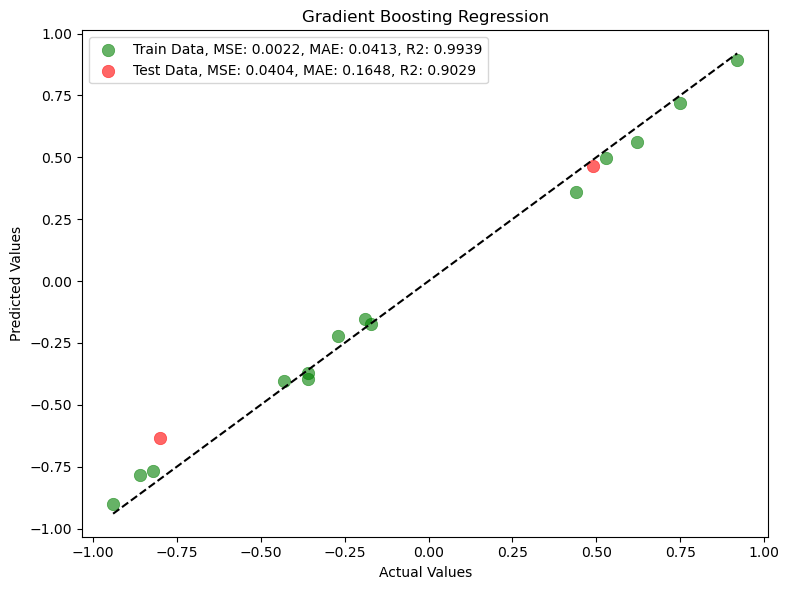

In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error  
import time
import matplotlib.pyplot as plt
import numpy as np

# Assuming data is already loaded

X = data.iloc[:, 1:-1].to_numpy()  # Features (all columns except first and last)
y = data.iloc[:, -1]  # Target (last column)

# Define hyperparameter grid for RandomizedSearchCV
param_grid = {
    "n_estimators": [350],
    "max_depth": [28],  
    "learning_rate": [0.2],
    "min_samples_leaf": [1],
    "max_features": [2],
    "min_samples_split": [6],
    "min_weight_fraction_leaf": [0],
    "min_impurity_decrease": [0.008],
    "alpha": [0.6]
}
time_start = time.time()

# Split data for training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=940)

# Normalize data
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_normalized = scaler.transform(X_train)
X_test_normalized = scaler.transform(X_test)

# Define the Gradient Boost regressor
GBR = GradientBoostingRegressor()

# Perform RandomizedSearchCV for hyperparameter tuning
grid_search = RandomizedSearchCV(GBR, param_grid, n_iter=10, cv=5,n_jobs=-1, scoring='r2')
grid_search.fit(X_train_normalized, y_train)

# Get the best model from the RandomizedSearchV
best_model = grid_search.best_estimator_

# Initialize lists to store metrics for each iteration
train_r2_scores = []
test_r2_scores = []
train_mse_scores = []
test_mse_scores = []
train_mae_scores = []  # Initialize list for MAE scores
test_mae_scores = []   # Initialize list for MAE scores

# Iterate through all 1000 iterations
for i in range(1, 10):
    # Train the model and make predictions
    best_model.fit(X_train_normalized, y_train)
    pred_train = best_model.predict(X_train_normalized)
    pred_test = best_model.predict(X_test_normalized)
    
    # Calculate R², MSE, and MAE for train and test data
    train_r2 = r2_score(y_train, pred_train)
    test_r2 = r2_score(y_test, pred_test)
    train_mse = mean_squared_error(y_train, pred_train)
    test_mse = mean_squared_error(y_test, pred_test)
    train_mae = mean_absolute_error(y_train, pred_train)  # Calculate MAE for train data
    test_mae = mean_absolute_error(y_test, pred_test)      # Calculate MAE for test data
    
    # Store the results
    train_r2_scores.append(train_r2)
    test_r2_scores.append(test_r2)
    train_mse_scores.append(train_mse)
    test_mse_scores.append(test_mse)
    train_mae_scores.append(train_mae)
    test_mae_scores.append(test_mae)

# Calculate averages of R², MSE, and MAE across all iterations
avg_train_r2 = np.mean(train_r2_scores)
avg_test_r2 = np.mean(test_r2_scores)
avg_train_mse = np.mean(train_mse_scores)
avg_test_mse = np.mean(test_mse_scores)
avg_train_mae = np.mean(train_mae_scores)  # Average MAE for Train
avg_test_mae = np.mean(test_mae_scores)    # Average MAE for Test




# Print average metrics
print(f"Average R² for Train: {avg_train_r2:.4f}")
print(f"Average R² for Test: {avg_test_r2:.4f}")
print(f"Average MSE for Train: {avg_train_mse:.4f}")
print(f"Average MSE for Test: {avg_test_mse:.4f}")
print(f"Average MAE for Train: {avg_train_mae:.4f}")  # Print Average MAE for Train
print(f"Average MAE for Test: {avg_test_mae:.4f}")    # Print Average MAE for Test

# End time for performance measurement
time_end = time.time()
time_sum = time_end - time_start
print(f"Time Taken for 1000 iterations: {time_sum:.2f} seconds")

# Visualize results for the last iteration
plt.figure(figsize=(8, 6))
plt.scatter(y_train, pred_train, label=f'Train Data, MSE: {avg_train_mse:.4f}, MAE: {avg_train_mae:.4f}, R2: {avg_train_r2:.4f}', color="green", alpha=0.6, s=80, linewidth=0.5) 
plt.scatter(y_test, pred_test, label=f'Test Data, MSE: {avg_test_mse:.4f}, MAE: {avg_test_mae:.4f}, R2: {avg_test_r2:.4f}', color="red", alpha=0.6, s=80, linewidth=0.5)
plt.plot([min(y), max(y)], [min(y), max(y)], linestyle="--", color="black")
plt.title("Gradient Boosting Regression")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()
plt.tight_layout()
plt.show()

Train R²: 0.9983
Test R²: 0.9983
Train MSE: 0.0015
Test MSE: 0.0017
Train MAE: 0.0286
Test MAE: 0.0374

散点图已保存为：/home/ggx/wls/lh/COOH/GBR/绘图/regression_results.png

特征重要性已保存为：/home/ggx/wls/lh/COOH/GBR/绘图/feature_importances.xlsx


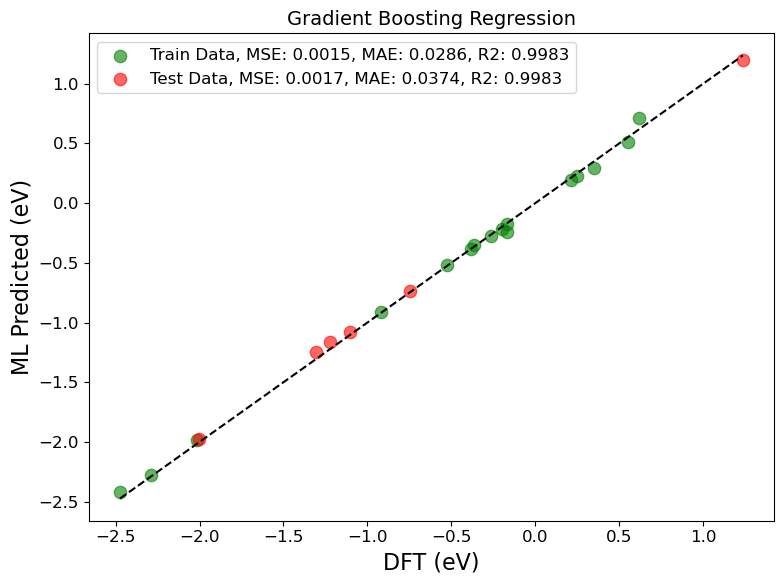

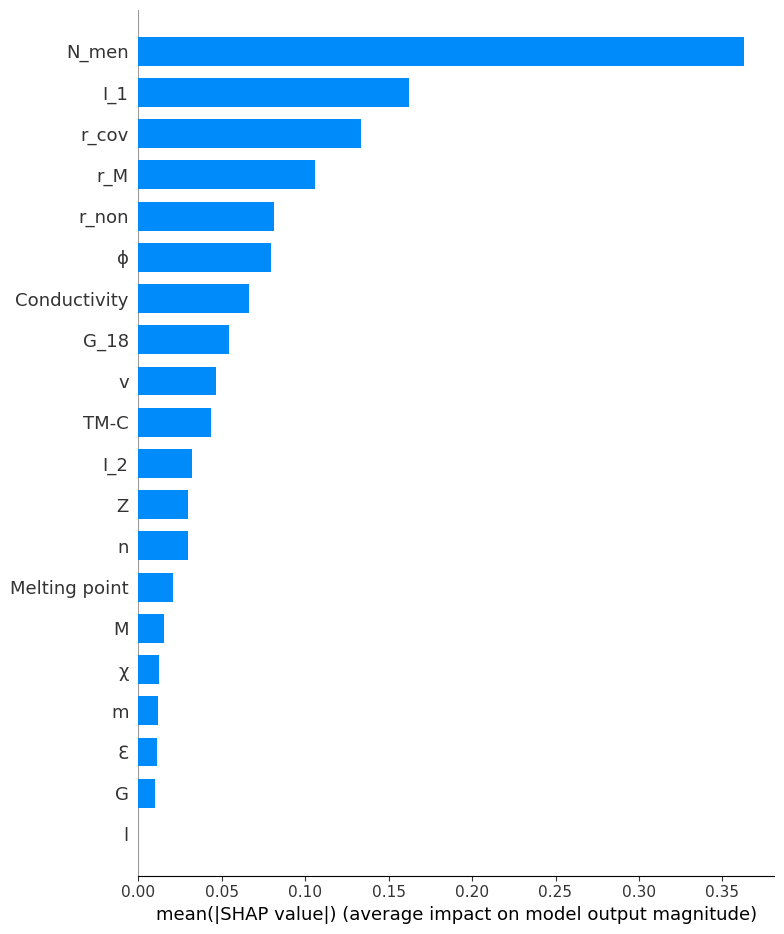


SHAP总结图已保存为：/home/ggx/wls/lh/COOH/GBR/绘图/shap_summary.png


<Figure size 640x480 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

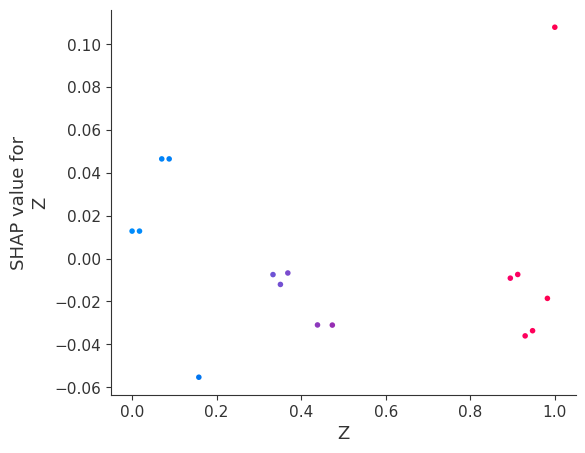


SHAP依赖图已保存为：/home/ggx/wls/lh/COOH/GBR/绘图/shap_dependence.png

DFT和ML散点图的数据已保存为：/home/ggx/wls/lh/COOH/GBR/绘图/dft_ml_scatter_data.xlsx


<Figure size 640x480 with 0 Axes>

In [3]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib  # 用于加载保存的模型
import matplotlib.pyplot as plt
import numpy as np
import shap  # 用于SHAP分析

# 设置全局字体大小
plt.rcParams.update({'font.size': 12})  # 设置全局字体大小为12

# 从Excel文件中读取数据
data = pd.read_excel('/home/ggx/wls/lh/COOH/data/cooh.xlsx')
 
X = data.iloc[:, 1:-1].to_numpy()  # Features (all columns except first and last)
y = data.iloc[:, -1]  # Target (last column)

# 加载保存的最佳模型和Scaler
best_model_filename = '/home/ggx/wls/lh/COOH/GBR/best_test_model.pkl'
best_scaler_filename = '/home/ggx/wls/lh/COOH/GBR/best_scaler.pkl'

best_model = joblib.load(best_model_filename)
best_scaler = joblib.load(best_scaler_filename)

# 分割数据集
X_train, X_test, y_train, y_test = train_test_split(X, y)

# 使用加载的Scaler对数据进行归一化
X_train_normalized = best_scaler.transform(X_train)
X_test_normalized = best_scaler.transform(X_test)

# 使用加载的模型进行预测
pred_train = best_model.predict(X_train_normalized)
pred_test = best_model.predict(X_test_normalized)

# 计算评估指标
train_r2 = r2_score(y_train, pred_train)
test_r2 = r2_score(y_test, pred_test)
train_mse = mean_squared_error(y_train, pred_train)
test_mse = mean_squared_error(y_test, pred_test)
train_mae = mean_absolute_error(y_train, pred_train)
test_mae = mean_absolute_error(y_test, pred_test)

# 打印评估指标
print(f"Train R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")
print(f"Train MSE: {train_mse:.4f}")
print(f"Test MSE: {test_mse:.4f}")
print(f"Train MAE: {train_mae:.4f}")
print(f"Test MAE: {test_mae:.4f}")

# 可视化结果
plt.figure(figsize=(8, 6))
plt.scatter(y_train, pred_train, label=f'Train Data, MSE: {train_mse:.4f}, MAE: {train_mae:.4f}, R2: {train_r2:.4f}', color="green", alpha=0.6, s=80, linewidth=0.9)
plt.scatter(y_test, pred_test, label=f'Test Data, MSE: {test_mse:.4f}, MAE: {test_mae:.4f}, R2: {test_r2:.4f}', color="red", alpha=0.6, s=80, linewidth=0.9)
plt.plot([min(y), max(y)], [min(y), max(y)], linestyle="--", color="black")

# 设置标题和标签的字体大小
plt.title("Gradient Boosting Regression", fontsize=14)  # 标题字体大小
plt.xlabel("DFT (eV)", fontsize=16)  # x轴标签字体大小
plt.ylabel("ML Predicted (eV)", fontsize=16)  # y轴标签字体大小

# 设置图例的字体大小
plt.legend(fontsize=12)

plt.tight_layout()

# 保存散点图到当前文件夹
current_directory = os.getcwd()  # 获取当前工作目录
scatter_plot_filename = os.path.join(current_directory, "regression_results.png")
plt.savefig(scatter_plot_filename)  # 保存图像
print(f"\n散点图已保存为：{scatter_plot_filename}")

# 如果需要显示图像，可以取消注释以下代码
# plt.show()

# 输出特征重要性到Excel
feature_importances = best_model.feature_importances_
feature_names = data.columns[1:-1]  # 获取特征名称（除去第一列和最后一列的列名）

# 创建一个DataFrame来存储特征重要性
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# 按重要性降序排序
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 保存到Excel文件
importance_excel_filename = os.path.join(current_directory, "feature_importances.xlsx")
importance_df.to_excel(importance_excel_filename, index=False)
print(f"\n特征重要性已保存为：{importance_excel_filename}")

# SHAP分析
# 初始化SHAP解释器
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_train_normalized)

# 绘制SHAP总结图
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_train_normalized, feature_names=feature_names, plot_type="bar")
shap_summary_filename = os.path.join(current_directory, "shap_summary.png")
plt.savefig(shap_summary_filename)
print(f"\nSHAP总结图已保存为：{shap_summary_filename}")

# 绘制SHAP依赖图（以第一个特征为例）
plt.figure(figsize=(10, 8))
shap.dependence_plot(0, shap_values, X_train_normalized, feature_names=feature_names)
shap_dependence_filename = os.path.join(current_directory, "shap_dependence.png")
plt.savefig(shap_dependence_filename)
print(f"\nSHAP依赖图已保存为：{shap_dependence_filename}")

# 输出DFT和ML散点图的数据到Excel
# 创建一个新的DataFrame，包含训练集和测试集的真实值和预测值
train_data = pd.DataFrame({'DFT (eV)': y_train, 'ML Predicted (eV)': pred_train})
test_data = pd.DataFrame({'DFT (eV)': y_test, 'ML Predicted (eV)': pred_test})

# 合并训练集和测试集的数据
combined_data = pd.concat([train_data, test_data], keys=['Train', 'Test']).reset_index(level=0)
combined_data.columns = ['Dataset', 'DFT (eV)', 'ML Predicted (eV)']

# 保存到Excel文件
combined_excel_filename = os.path.join(current_directory, "dft_ml_scatter_data.xlsx")
combined_data.to_excel(combined_excel_filename, index=False)
print(f"\nDFT和ML散点图的数据已保存为：{combined_excel_filename}")

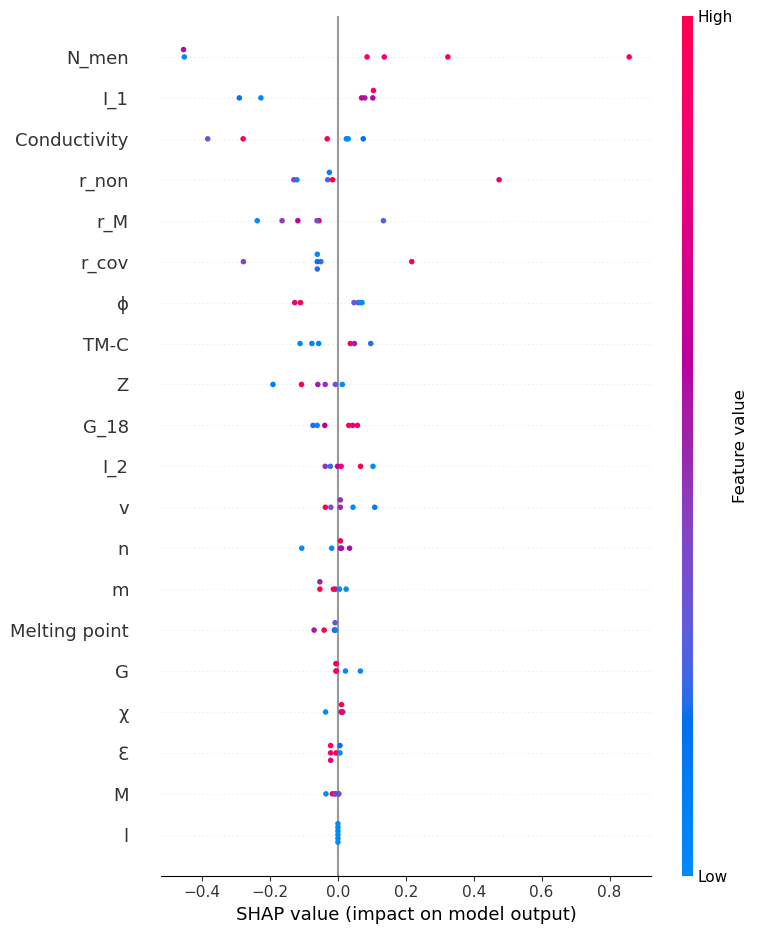


SHAP图已保存为：/home/ggx/wls/lh/COOH/GBR/绘图/shap_summary.png


<Figure size 640x480 with 0 Axes>

In [4]:
plt.show()

# 使用SHAP进行特征重要性分析
explainer = shap.Explainer(best_model)
shap_values = explainer(X_test_normalized)

# 绘制SHAP总结图
shap.summary_plot(shap_values, X_test_normalized, feature_names=data.columns[1:-1])

# 保存SHAP图到当前文件夹
shap_plot_filename = os.path.join(current_directory, "shap_summary.png")
plt.savefig(shap_plot_filename)
print(f"\nSHAP图已保存为：{shap_plot_filename}")

plt.show()